# L3 —— Mast细胞的亚群识别

In [29]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L3/immune"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(ANNO_DIR, "L3_immune_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_Mast_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L3_Mast_summary.csv")

## 数据读取


In [30]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 187365 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'L2_celltype_sub_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 查看L2注释结果

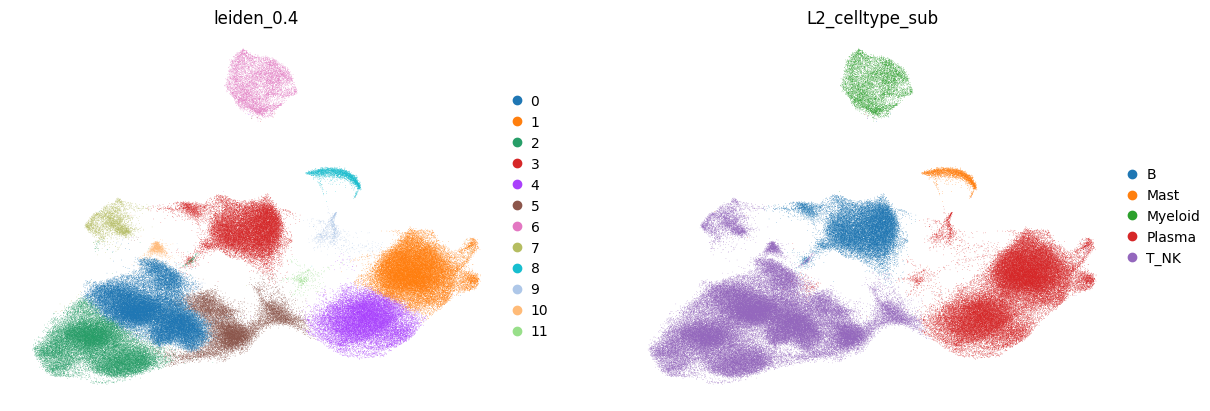

In [31]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,
)

In [32]:
adata.obs["L2_celltype_sub"].value_counts()

L2_celltype_sub
T_NK       95433
Plasma     58095
B          23996
Myeloid     7272
Mast        2569
Name: count, dtype: int64

## 对Mast细胞进行细分

In [33]:
sub = adata[adata.obs["L2_celltype_sub"]=="Mast"].copy()
sub

AnnData object with n_obs × n_vars = 2569 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'L2_celltype_sub_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

简化一下亚群对象

In [34]:
# 1. 删除之前的降维
for key in ["X_pca", "X_pca_harmony", "X_scVI", "X_umap"]:
    if key in sub.obsm:
        del sub.obsm[key]
# 2. 删除之前的 graph（neighbors）
for key in ["neighbors"]:
    if key in sub.uns:
        del sub.uns[key]
for key in ["distances", "connectivities"]:
    if key in sub.obsp:
        del sub.obsp[key]
# 4. 删除 var 中不再需要的高变基因标记
for key in ["highly_variable", "highly_variable_rank",
            "means", "variances", "variances_norm"]:
    if key in sub.var:
        del sub.var[key]
# 5. 删除 uns 中各种配色、聚类结果、rank_genes_groups
keys_to_remove = [
    k for k in sub.uns.keys()
    if ("colors" in k) or ("leiden" in k) or ("rank_genes_groups" in k)
]
for k in keys_to_remove:
    del sub.uns[k]
sub

AnnData object with n_obs × n_vars = 2569 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [35]:
# 若有原始计数，先切回 counts 再开始标准流程
if "counts" in sub.layers:
    sub.X = sub.layers["counts"]

## HVG → PCA → Harmony → neighbors → leiden

In [36]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)
sub

AnnData object with n_obs × n_vars = 2569 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [37]:
# 标记 HVG，但不裁剪基因
sc.pp.highly_variable_genes(
    sub, n_top_genes=2000, flavor="seurat_v3",
    subset=False, span=0.5, check_values=False
)
hv_mask = sub.var["highly_variable"].values

In [38]:
# 仅在 HVG 上做 PCA（不丢非HVG；把结果写回到 sub）
sub_hv = sub[:, hv_mask].copy()
sc.pp.scale(sub_hv, max_value=10)
sc.tl.pca(sub_hv, n_comps=50, svd_solver="arpack")
sub.obsm["X_pca"] = sub_hv.obsm["X_pca"]
sub

AnnData object with n_obs × n_vars = 2569 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca'
    layers: 'counts'

根据不同的数据集批次去除批次效应

In [39]:
# Harmony 去批次（基于 PCA）
sce.pp.harmony_integrate(sub, key="GSE", basis="X_pca")
sub

2025-12-01 22:49:12,986 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-01 22:49:14,713 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-01 22:49:14,761 - harmonypy - INFO - Iteration 1 of 10
2025-12-01 22:49:16,429 - harmonypy - INFO - Iteration 2 of 10
2025-12-01 22:49:17,091 - harmonypy - INFO - Converged after 2 iterations


AnnData object with n_obs × n_vars = 2569 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca', 'X_pca_harmony'
    layers: 'counts'

In [40]:
# 邻域/聚类/UMAP
sc.pp.neighbors(sub, use_rep="X_pca_harmony", n_neighbors=20)
sc.tl.umap(sub)

In [41]:
sc.tl.leiden(sub, resolution=0.1, key_added=f"leiden_0.1_Mast")
sc.tl.leiden(sub, resolution=0.2, key_added=f"leiden_0.2_Mast")

查看批次效应

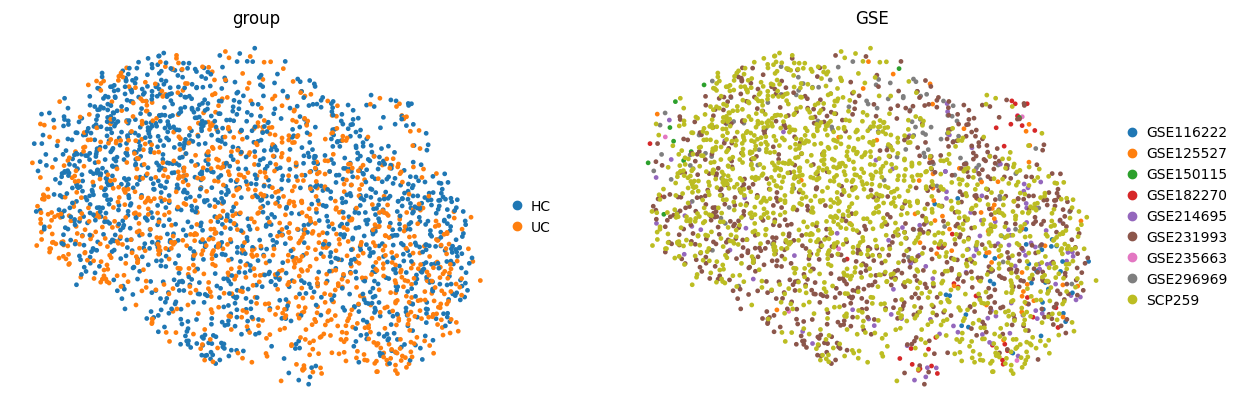

In [42]:
sc.pl.umap(sub, color=['group','GSE'], frameon=False)

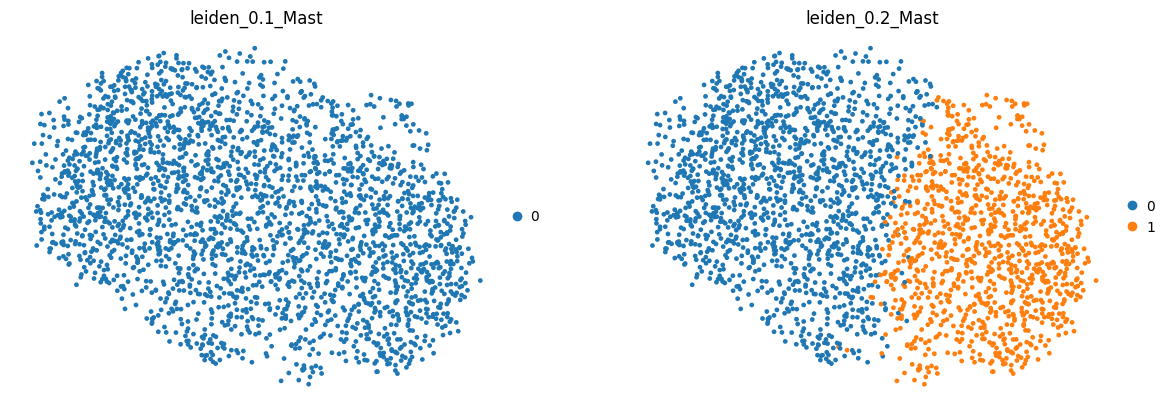

In [43]:
sc.pl.umap(sub, color=['leiden_0.1_Mast','leiden_0.2_Mast'], frameon=False)

## 查看marker表达

In [44]:
l3_mast_markers = {
    # --- 核心亚型 ---
    "MC_T": ["TPSAB1", "TPSB2"],             # 仅表达胰蛋白酶 (粘膜型)
    "MC_TC": ["TPSAB1", "CMA1", "CPA3"],     # 表达胰蛋白酶 + 糜蛋白酶 (结缔组织型)
    
    # --- 活化/功能 ---
    "MC_Activated": ["MRGPRX2", "TNF", "IL1B"], # UC 炎症相关
    "MC_Prolif": ["MKI67", "TOP2A"]
}
# 辅助函数：检查基因是否存在于数据集中，防止报错
def safe_genes(genes, sub):
    valid_genes = [g for g in genes if g in sub.var_names]
    if len(valid_genes) < len(genes):
        print(f"Warning: 忽略了缺失基因: {set(genes) - set(valid_genes)}")
    return valid_genes

正在绘制 MC_Activated Markers...


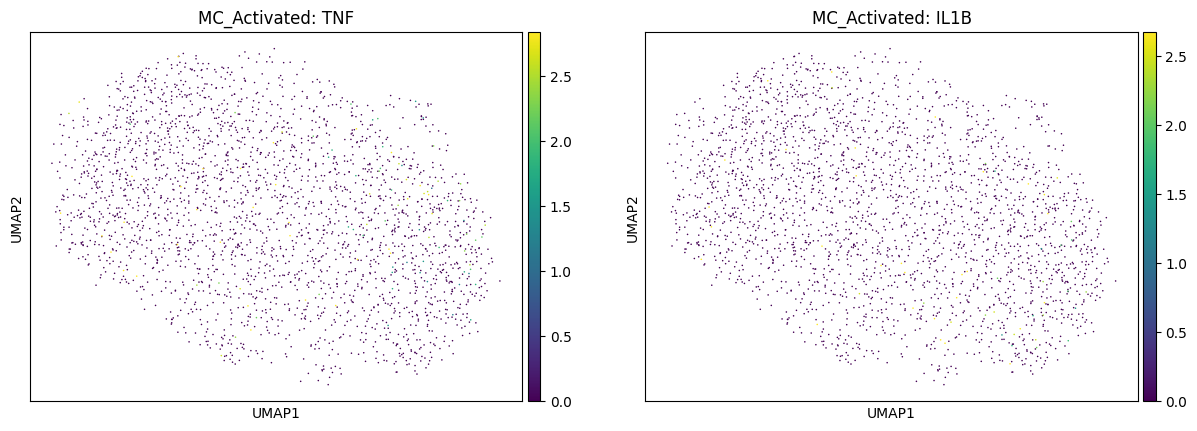

In [45]:
print("正在绘制 MC_Activated Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_mast_markers["MC_Activated"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"MC_Activated: {g}" for g in safe_genes(l3_mast_markers["MC_Activated"], sub)])

正在绘制 MC_Prolif Markers...


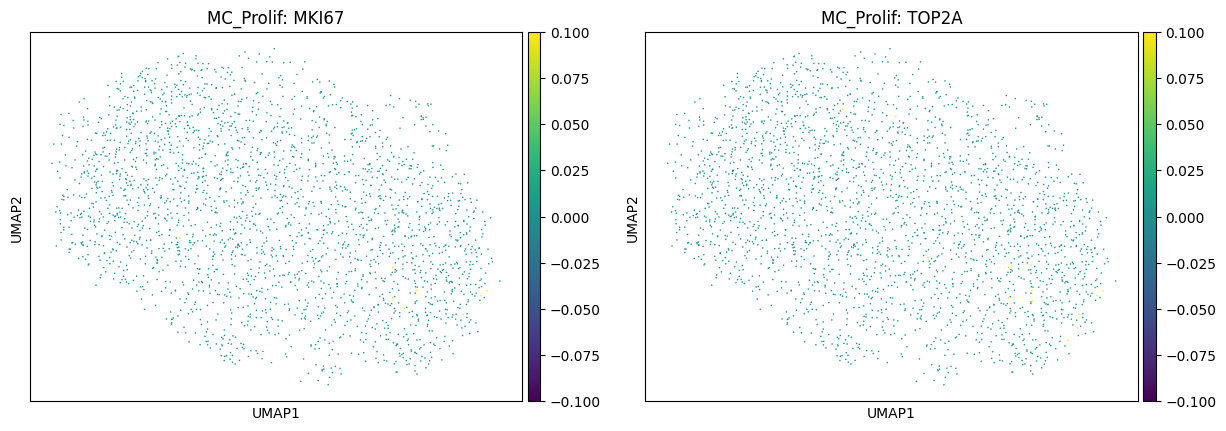

In [46]:
print("正在绘制 MC_Prolif Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_mast_markers["MC_Prolif"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"MC_Prolif: {g}" for g in safe_genes(l3_mast_markers["MC_Prolif"], sub)])

## 差异分析

In [47]:
sub

AnnData object with n_obs × n_vars = 2569 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.1_Mast', 'leiden_0.2_Mast'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'leiden_0.1_Mast', 'leiden_0.2_Mast', 'group_colors', 'GSE_colors', 'leiden_0.1_Mast_colors', 'leiden_0.2_Mast_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

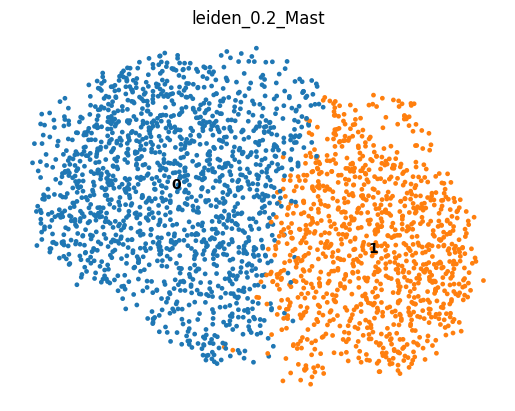

In [48]:
sc.pl.umap(sub, color=['leiden_0.2_Mast'], frameon=False, ncols=2, legend_loc='on data')

In [49]:
if 'leiden_0.2_Mast' in sub.obs.columns:
    sub.obs['leiden_0.2_Mast'] = sub.obs['leiden_0.2_Mast'].astype('category')

# 2. 运行差异分析
print("正在进行差异基因分析...")
sc.tl.rank_genes_groups(
    sub, 
    groupby='leiden_0.2_Mast', 
    method='wilcoxon', 
    use_raw=True, 
    pts=True
)
print("分析完成！")

正在进行差异基因分析...
分析完成！


In [50]:
# 获取所有分组的名称
groups = sub.obs['leiden_0.2_Mast'].cat.categories

# 初始化一个字典来存储结果
top10_genes = {}

print("=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===")
for group in groups:
    # 提取该群的差异基因数据框
    df = sc.get.rank_genes_groups_df(sub, group=group)
    
    # 筛选条件：通常我们关注上调的基因 (logfoldchanges > 0)
    # 按 score 降序排列（score 综合了表达差异和显著性）
    top_genes = df[df['logfoldchanges'] > 0].sort_values('scores', ascending=False).head(10)['names'].tolist()
    
    top10_genes[group] = top_genes
    print(f"Cluster {group}: {', '.join(top_genes)}")

# 如果你想把这个 Top10 列表存成一个 DataFrame 方便查看：
df_top10 = pd.DataFrame(top10_genes)
print("\nTop 10 基因表格预览：")
#display(df_top10)

# 可选：保存到 CSV
# df_top10.to_csv("L3_TNK_Top10_Markers.csv")

=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===
Cluster 0: RPL7, H3F3B, UBB, RPL21, RPS19, RPS14, RPL15, RPL3, RPS4X, FTL
Cluster 1: ACTG1, RAC2, LAPTM5, CFL1, TAGLN2, CD44, HNRNPC, SUB1, PPIA, HSP90B1

Top 10 基因表格预览：


## 结果

In [51]:
sub.obs['L3'] = sub.obs['L2_celltype_sub'].copy()

# 检查一下是否成功
print(sub.obs[['L2_celltype_sub', 'L3']].head())

                             L2_celltype_sub    L3
GSM8980878_UC68_CELL3777_N2             Mast  Mast
GSM8980878_UC68_CELL5534_N3             Mast  Mast
GSM8980878_UC68_CELL5997_N2             Mast  Mast
GSM8980878_UC68_CELL9765_N2             Mast  Mast
GSM8980878_UC68_CELL11529_N2            Mast  Mast


In [52]:
wanted_cols = [
    "GSM", "GSE", "group",
    "L1_lineage"             
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
    'L3'
]
out_cols = [c for c in wanted_cols if c in sub.obs.columns]

sub.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/immune/L3_Mast_summary.csv


In [53]:
sub.write_h5ad(OUT_H5AD, compression="gzip")